In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pratham00727829/deepfashion2-protected-z/json_for_validation.enc
/kaggle/input/datasets/pratham00727829/deepfashion2-protected-z/train.enc
/kaggle/input/datasets/pratham00727829/deepfashion2-protected-z/validation.enc
/kaggle/input/datasets/pratham00727829/deepfashion2-protected-z/test.enc


In [2]:
import os
import glob
import json
import shutil
from collections import Counter

working_dir = "/kaggle/working/deepfashion2"
output_dir = '/kaggle/working/preprocessed_dataset'

print("🧹 PHASE 1: Wiping old partial extractions to free up 20GB disk space...")
if os.path.exists(working_dir):
    shutil.rmtree(working_dir)
os.makedirs(working_dir, exist_ok=True)

print("🚀 PHASE 2: Extracting Train & Validation sets (Skipping Test to save space)...")
enc_files = glob.glob('/kaggle/input/**/*.enc', recursive=True)

for enc_path in enc_files:
    if 'test' in enc_path.lower(): continue # Skip test to save memory
        
    if 'train' in enc_path.lower(): target = "train_images"
    elif 'validation' in enc_path.lower() or 'val' in enc_path.lower(): target = "validation_images"
    else: continue
        
    target_folder = os.path.join(working_dir, target)
    os.makedirs(target_folder, exist_ok=True)
    
    temp_zip = f"/kaggle/working/temp_{os.path.basename(enc_path)}.zip"
    if os.path.exists(temp_zip): os.remove(temp_zip)
    os.symlink(enc_path, temp_zip)
    
    !unzip -q -o -P '2019Deepfashion2**' "{temp_zip}" -d "{target_folder}"
    os.remove(temp_zip)

print("\n🧠 PHASE 3: PREPROCESSING TOP 5 & BUILDING SPLITS")
splits_to_process = {'train': 'train_images', 'val': 'validation_images'}

train_annos = glob.glob(os.path.join(working_dir, splits_to_process['train'], '**', '*.json'), recursive=True)
category_counts = Counter()
for anno in train_annos:
    with open(anno, 'r') as f:
        for k, v in json.load(f).items():
            if k.startswith('item'): category_counts[v['category_id']] += 1

top_5_categories = [c for c, _ in category_counts.most_common(5)]
total_train_items = sum([category_counts[c] for c in top_5_categories])

class_weights = {c: round(total_train_items / (5 * category_counts[c]), 4) for c in top_5_categories}
os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, 'class_weights.json'), 'w') as f: json.dump(class_weights, f, indent=4)

for split_name, folder_name in splits_to_process.items():
    split_source = os.path.join(working_dir, folder_name)
    if not os.path.exists(split_source): continue
        
    images = glob.glob(os.path.join(split_source, '**', '*.jpg'), recursive=True)
    anno_map = {os.path.basename(p).replace('.json', ''): p for p in glob.glob(os.path.join(split_source, '**', '*.json'), recursive=True)}
    
    split_dest = os.path.join(output_dir, split_name, 'images')
    os.makedirs(split_dest, exist_ok=True)
    
    split_annotations = []
    for img_path in images:
        base = os.path.basename(img_path).replace('.jpg', '')
        if base in anno_map:
            with open(anno_map[base], 'r') as f:
                data = json.load(f)
                valid_items = [{'category_id': i['category_id'], 'bounding_box': i['bounding_box'], 'segmentation': i.get('segmentation', [])} 
                               for k, i in data.items() if k.startswith('item') and i['category_id'] in top_5_categories]
                
            if valid_items:
                dest_img = os.path.join(split_dest, os.path.basename(img_path))
                if not os.path.exists(dest_img): os.symlink(img_path, dest_img)
                split_annotations.append({'image_file': os.path.basename(img_path), 'items': valid_items})

    if split_annotations:
        with open(os.path.join(output_dir, split_name, f'{split_name}_annotations.json'), 'w') as f:
            json.dump(split_annotations, f, indent=4)

# Generate Vansh's Required Label Map
label_map = {"short sleeve top": 0, "trousers": 1, "shorts": 2, "long sleeve top": 3, "skirt": 4}
with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("\n🎉 PIPELINE COMPLETE! Dataset preprocessed and label_map.json is generated.")

🧹 PHASE 1: Wiping old partial extractions to free up 20GB disk space...
🚀 PHASE 2: Extracting Train & Validation sets (Skipping Test to save space)...

🧠 PHASE 3: PREPROCESSING TOP 5 & BUILDING SPLITS

🎉 PIPELINE COMPLETE! Dataset preprocessed and label_map.json is generated.


✅ PyTorch Dataset ready: 144174 images in the TRAIN split!


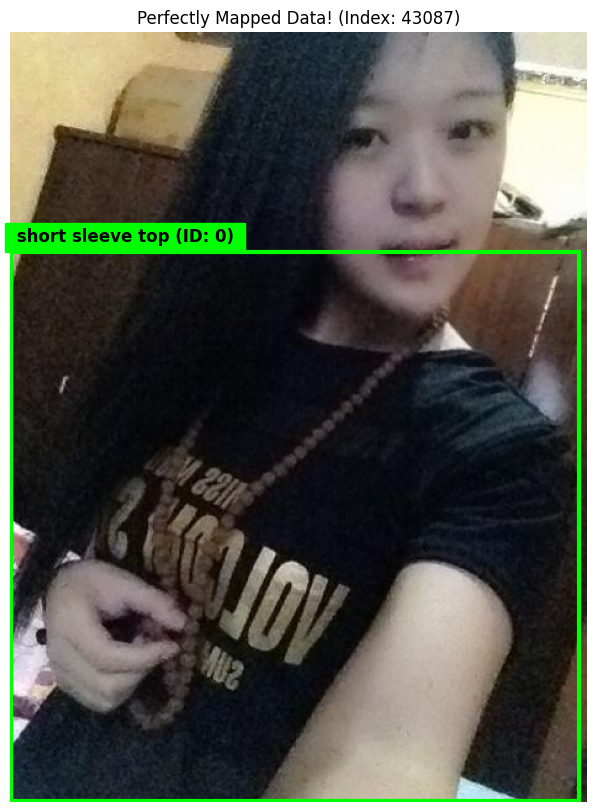

In [3]:
import torch
import os
import json
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

class DeepFashion2Optimized(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.image_dir = os.path.join(root_dir, split, 'images')
        self.transform = transform
        
        json_path = os.path.join(root_dir, split, f'{split}_annotations.json')
        with open(json_path, 'r') as f:
            self.data = json.load(f)
            
        # Vansh's exact required mapping
        self.id_to_new_label = {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
            
        print(f"✅ PyTorch Dataset ready: {len(self.data)} images in the {split.upper()} split!")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item_data = self.data[idx]
        img_path = os.path.join(self.image_dir, item_data['image_file'])
        
        image = Image.open(img_path).convert("RGB")
        boxes, labels = [], []
        
        for item in item_data['items']:
            boxes.append(item['bounding_box']) 
            # Translate to the 0-4 label format instantly
            labels.append(self.id_to_new_label[item['category_id']])
            
        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.empty((0, 4), dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.empty((0,), dtype=torch.int64)
        
        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        
        if self.transform: pass
            
        return image, target

# --- Visual Verification ---
preprocessed_dir = '/kaggle/working/preprocessed_dataset'
train_dataset = DeepFashion2Optimized(root_dir=preprocessed_dir, split='train')

idx = random.randint(0, len(train_dataset) - 1)
image, target = train_dataset[idx]

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(image)
names = {0: "short sleeve top", 1: "trousers", 2: "shorts", 3: "long sleeve top", 4: "skirt"}

for box, label in zip(target['boxes'], target['labels']):
    xmin, ymin, xmax, ymax = box.numpy()
    width, height = xmax - xmin, ymax - ymin
    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=3, edgecolor='#00ff00', facecolor='none')
    ax.add_patch(rect)
    
    label_val = label.item()
    ax.text(xmin, ymin - 8, f' {names[label_val]} (ID: {label_val}) ', color='black', fontsize=12, weight='bold', backgroundcolor='#00ff00')

plt.axis('off')
plt.title(f"Perfectly Mapped Data! (Index: {idx})")
plt.show()

In [4]:
import os
import glob
import json
from collections import Counter

# --- Directories ---
working_dir = '/kaggle/working/deepfashion2'
output_dir = '/kaggle/working/preprocessed_dataset'
splits_to_process = {'train': 'train_images', 'val': 'validation_images'}

print("Step 1: Calculating Top 5 Categories from the TRAINING set only (Preventing Data Leakage)...")

# Grab ONLY the training annotations to figure out the Top 5
train_dir = os.path.join(working_dir, splits_to_process['train'])
train_annos = glob.glob(os.path.join(train_dir, '**', '*.json'), recursive=True)

category_counts = Counter()
for anno_path in train_annos:
    with open(anno_path, 'r') as f:
        data = json.load(f)
        for key, item in data.items():
            if key.startswith('item'):
                category_counts[item['category_id']] += 1

top_5_categories = [cat_id for cat_id, count in category_counts.most_common(5)]
print(f"✅ Top 5 Category IDs: {top_5_categories}")

# --- Weights ---
print("\nStep 2: Calculating Class Weights from Training set...")
total_train_items = sum([category_counts[cat_id] for cat_id in top_5_categories])
class_weights = {}

for cat_id in top_5_categories:
    weight = total_train_items / (len(top_5_categories) * category_counts[cat_id])
    class_weights[cat_id] = weight
    print(f"  Category {cat_id}: Weight {weight}")

os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, 'class_weights.json'), 'w') as f:
    json.dump(class_weights, f, indent=4)

# --- Pruning & Symlinking ---
print("\nStep 3: Pruning and building Kaggle-optimized directories...")

for split_name, folder_name in splits_to_process.items():
    print(f"\n--- Processing Official Split: {split_name.upper()} ---")
    
    split_source_dir = os.path.join(working_dir, folder_name)
    if not os.path.exists(split_source_dir):
        print(f"⚠️ Skipping {split_name} (Folder not found. Did you extract it?)")
        continue

    images = glob.glob(os.path.join(split_source_dir, '**', '*.jpg'), recursive=True)
    anno_map = {os.path.basename(p).replace('.json', ''): p for p in glob.glob(os.path.join(split_source_dir, '**', '*.json'), recursive=True)}
    
    split_dest_dir = os.path.join(output_dir, split_name, 'images')
    os.makedirs(split_dest_dir, exist_ok=True)
    
    split_annotations = []
    retained_images = 0

    for img_path in images:
        base_name = os.path.basename(img_path).replace('.jpg', '')
        
        # We STRICTLY require the JSON to filter the Top 5
        if base_name in anno_map:
            with open(anno_map[base_name], 'r') as f:
                data = json.load(f)
                
            valid_items = []
            for key, item in data.items():
                if key.startswith('item') and item['category_id'] in top_5_categories:
                    valid_items.append({
                        'category_id': item['category_id'],
                        'bounding_box': item['bounding_box'],
                        'segmentation': item.get('segmentation', [])
                    })
                    
            if valid_items:
                retained_images += 1
                dest_img_path = os.path.join(split_dest_dir, os.path.basename(img_path))
                
                # Disk-saving symlink
                if not os.path.exists(dest_img_path):
                    os.symlink(img_path, dest_img_path)
                    
                split_annotations.append({
                    'image_file': os.path.basename(img_path),
                    'items': valid_items
                })

    # Save the consolidated JSON for this specific split
    if split_annotations:
        json_output_path = os.path.join(output_dir, split_name, f'{split_name}_annotations.json')
        with open(json_output_path, 'w') as f:
            json.dump(split_annotations, f, indent=4)
            
    print(f"✅ Retained {retained_images} images containing Top 5 categories.")

# --- Label Generation ---
print("\nStep 4: Generating Vansh's Required label_map.json...")

# Vansh's exactly required formatting
label_map = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)
    
print("✅ label_map.json created successfully in /kaggle/working/!")

Step 1: Calculating Top 5 Categories from the TRAINING set only (Preventing Data Leakage)...
✅ Top 5 Category IDs: [1, 8, 7, 2, 9]

Step 2: Calculating Class Weights from Training set...
  Category 1: Weight 0.6435815479098332
  Category 8: Weight 0.8324949897990503
  Category 7: Weight 1.25926917194669
  Category 2: Weight 1.2785437000887312
  Category 9: Weight 1.4953591697746067

Step 3: Pruning and building Kaggle-optimized directories...

--- Processing Official Split: TRAIN ---
✅ Retained 144174 images containing Top 5 categories.

--- Processing Official Split: VAL ---
✅ Retained 23741 images containing Top 5 categories.

Step 4: Generating Vansh's Required label_map.json...
✅ label_map.json created successfully in /kaggle/working/!
